# Allen Institute Visual Behavior 2P dataset overview
### This dataset consists of neural activity measured with 2-photon calcium imaging in the visual cortex of mice performing an image change detection task.
##### In this task, mice learn to report changes in stimulus identity by licking a spout to earn a water reward.


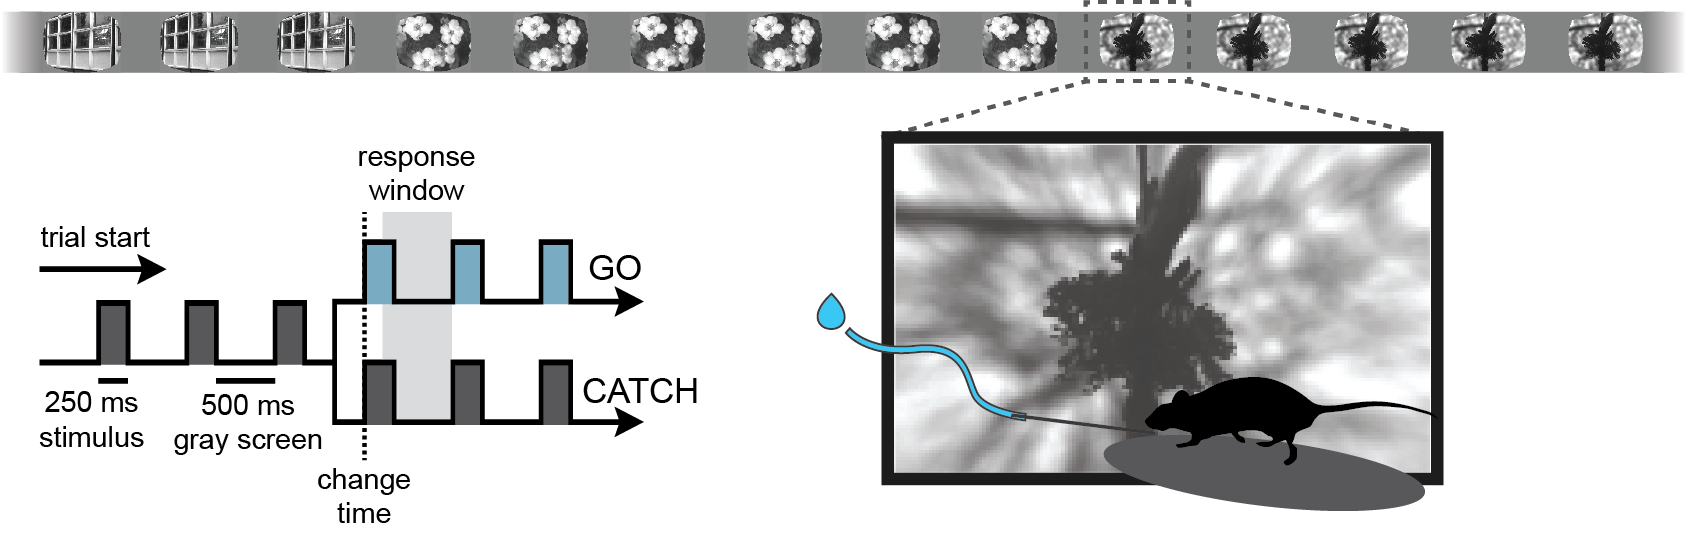

##### In some sessions, the mice perform the task with familiar images they have seen many times during training. In other sessions, mice perform the task with novel images.
##### During 2-photon imaging sessions, 5% of stimulus presentations are randomly omitted, allowing us to examine the effect of unexpected events on neural activity.
##### The same population of cells is imaged over multiple days with varying sensory and behavioral conditions.


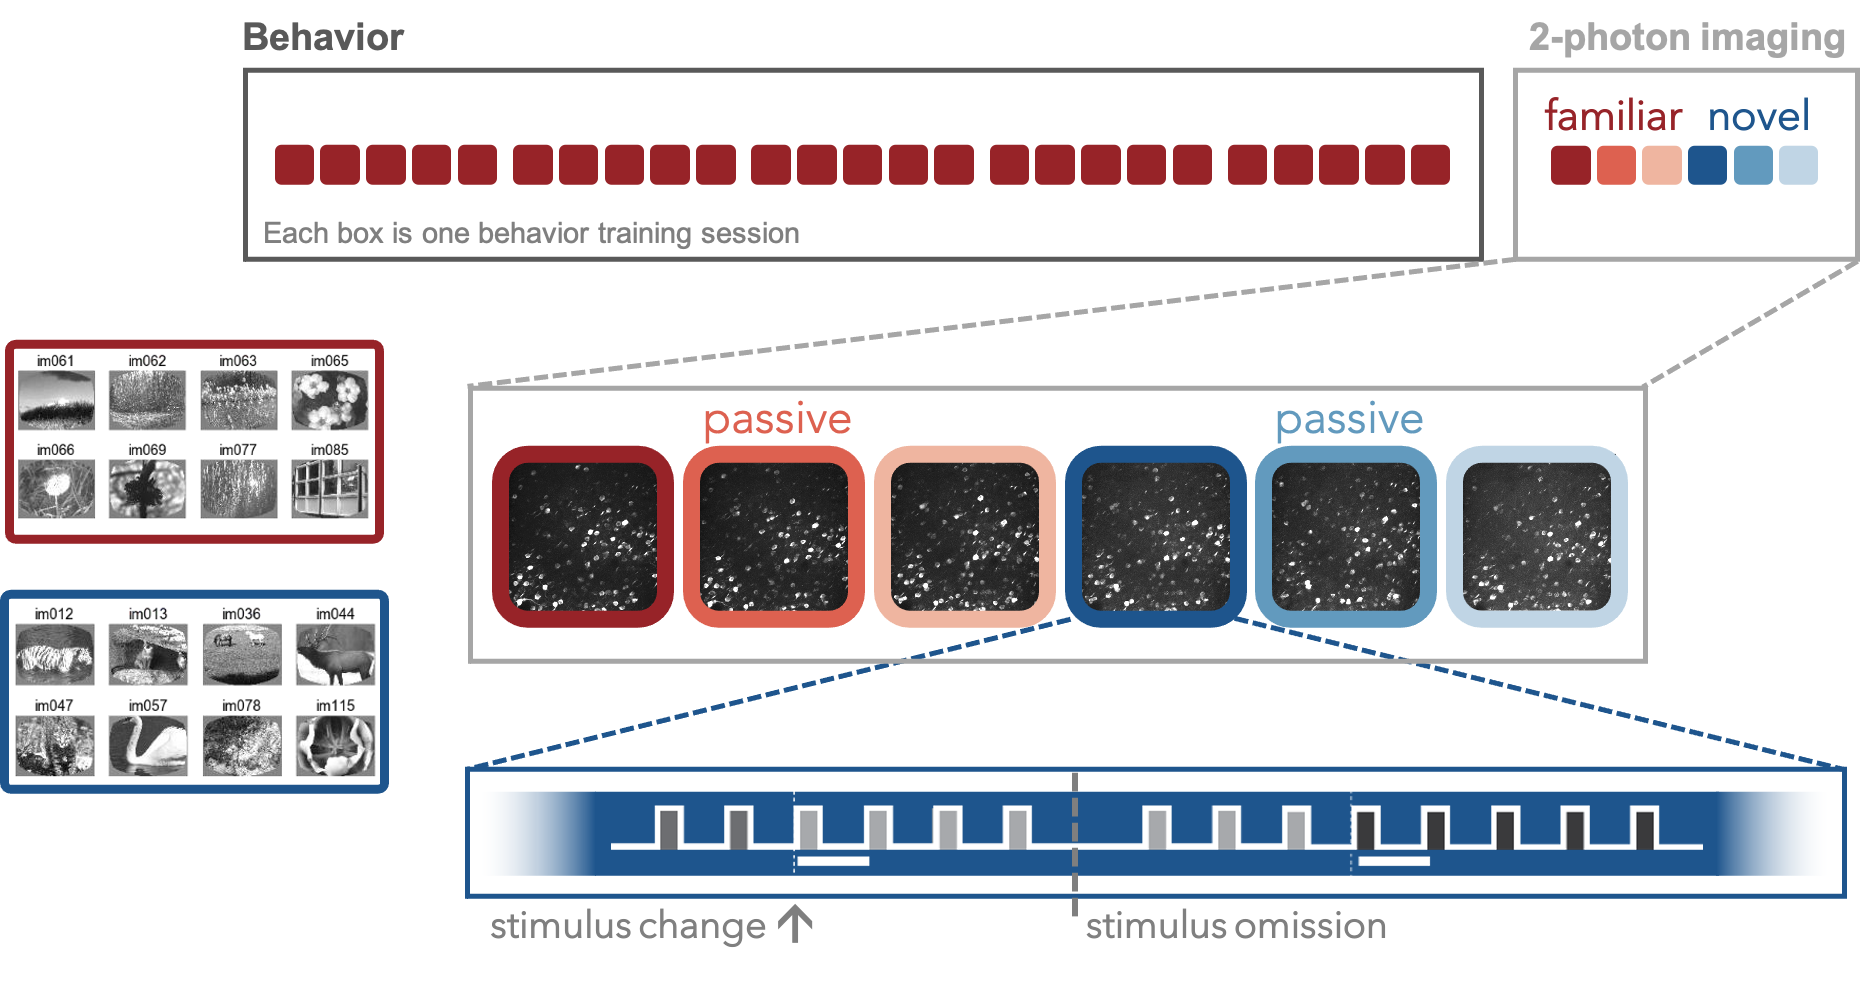

# Loading the data

In [ ]:
# @title Install dependencies

!pip install pandas --quiet
!pip install seaborn --quiet

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

## For this example, we have pre-computed event triggered responses and saved them to figshare.
#### To access the full dataset, see `Allen_neuromatch_example_2.ipynb`, or go to the links at the bottom of this notebook
###This cell will download the responses.

In [ ]:
# @title Data retrieval
import os, requests

fname = "allen_visual_behavior_2p_change_detection_familiar_novel_image_sets.parquet"
url = "https://ndownloader.figshare.com/files/28470255"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

### Then we open it using the pandas `read_parquet` method


(parquet is just another file format)

In [ ]:
filename = "allen_visual_behavior_2p_change_detection_familiar_novel_image_sets.parquet"
data = pd.read_parquet(filename)
mouses = data.mouse_id.unique()
data_mouses = {}
for m in mouses:
  #print(f"rat {m} \n")
  data_m = data[(data.mouse_id == m)]
  data_mouses[m] = {"familiar":data_m[(data_m.exposure_level == "familiar")],
                    "novel":data_m[(data_m.exposure_level == "novel")]}

data_mouses[mouses[0]]["familiar"]
# Crear un dict para las sesiones <tarea>.
#rat_1_s_1 =
#saber que hay en ophys

,stimulus_presentations_id,cell_specimen_id,trace,trace_timestamps,mean_response,baseline_response,image_name,image_index,is_change,omitted,...,ophys_session_id,ophys_container_id,behavior_session_id,full_genotype,reporter_line,driver_line,indicator,sex,age_in_days,exposure_level
85,5,1086496689,"[0.06366926431655884, 0.002476318972185254, -0...","[-1.228133913303992, -1.1958145997959921, -1.1...",0.006115,-0.084113,im075,2,True,False,...,994199725,991913453,994210659,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,196.0,familiar
86,5,1086501573,"[0.0637083426117897, 0.0919334813952446, -0.09...","[-1.228133913303992, -1.1958145997959921, -1.1...",-0.018832,-0.025578,im075,2,True,False,...,994199725,991913453,994210659,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,196.0,familiar
87,5,1086500533,"[0.0223990511149168, 0.22551870346069336, 0.11...","[-1.228133913303992, -1.1958145997959921, -1.1...",-0.041275,-0.032698,im075,2,True,False,...,994199725,991913453,994210659,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,196.0,familiar
88,5,1086497438,"[0.01795899122953415, 0.15271763503551483, 0.0...","[-1.228133913303992, -1.1958145997959921, -1.1...",0.039527,-0.026750,im075,2,True,False,...,994199725,991913453,994210659,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,196.0,familiar
89,5,1086497908,"[0.059766266494989395, 0.03602207452058792, 0....","[-1.228133913303992, -1.1958145997959921, -1.1...",-0.006628,-0.039277,im075,2,True,False,...,994199725,991913453,994210659,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,196.0,familiar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144080,4799,1086497034,"[0.13633622229099274, -0.033262453973293304, 0...","[-1.2281638329897349, -1.195843732121584, -1.1...",-0.019674,0.058517,im035,7,True,False,...,994731371,991913453,994743822,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,199.0,familiar
144081,4799,1086496500,"[0.2646369934082031, 0.16455529630184174, 0.10...","[-1.2281638329897349, -1.195843732121584, -1.1...",-0.024488,0.035993,im035,7,True,False,...,994731371,991913453,994743822,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,199.0,familiar
144082,4799,1086500121,"[-0.013596612960100174, 0.017643142491579056, ...","[-1.2281638329897349, -1.195843732121584, -1.1...",-0.018047,0.016095,im035,7,True,False,...,994731371,991913453,994743822,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,199.0,familiar
144083,4799,1086498820,"[0.7284610867500305, 0.47418925166130066, 0.71...","[-1.2281638329897349, -1.195843732121584, -1.1...",0.137925,-0.124559,im035,7,True,False,...,994731371,991913453,994743822,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,Ai148(TIT2L-GC6f-ICL-tTA2),[Sst-IRES-Cre],GCaMP6f,M,199.0,familiar



##### Available data includes:
*   The cell `trace` aligned to stimulus (or omission) onset in a [-1.25, 1.5] second window around onset time
    *   Cell traces are in units of delta F/F, the change in fluorescence relative to baseline
*   The `trace_timestamps` for each trial, aligned to stimulus or omission onset
*   The `mean_response` on a given trial in a 500ms window after stimulus onset
*   The `baseline_response` on a given trial in a 500ms window before stimulus onset
*   The `image_name` for each trial. Trials where the stimulus was omitted have `image_name` = `omitted`
*   The `mean_running_speed` in a 500ms window after stimulus onset
*   The `mean_pupil_area` in a 500ms window after stimulus onset
*   The `response_latency` when the mouse licked after stimulus onset
*   Whether or not the trial was `rewarded`
*   Whether or not the trial `is_change`
*   Whether or not the trial was `omitted`

#### Cell and session level metadata includes:

*   The `stimulus_presentations_id` indicating the trial number within the session
*   The `cell_specimen_id` which is the unique identifier for each cell (note that a cell can be imaged in multiple sessions; if that's the case, the same cell_specimen_id appears in multiple sessions)
*   The `cre_line` indicating the cell type
  *   `Sst-IRES-Cre` labels SST inhibitory cells
  *   `Vip-IRES-Cre` labels VIP inhibitory cells
  *   `Slc17a7-IRES-Cre` labels excitatory cells
*   The `imaging_depth` indicating the cortical depth where the cell was located
*   The `targeted_structure` indicating the cortical area the cell was from
*   The `session_type` indicating the session order and image set
*   The `exposure_level` which tells you whether the image set was familiar or novel
*   The `mouse_id` indicating which mouse the cell came from
*   The `ophys_session_id` indicating the recording day for that trial
*   The `ophys_experiment_id` indicating which imaging plane within the session that the cell came from
*   The `ophys_container_id` which links the same imaging plane recorded across multiple sessions. Cells that are imaged across multiple sessions will have the same `cell_specimen_id`.





# How are VIP and SST cells affected by stimulus novelty?

In [ ]:
import math

needed_bool = []
#Si es un False, es porque el dato era un NaN
for i in range (0,len(data.index)):
    if math.isnan(data.iloc[i]["response_latency"])==True:
        needed_bool.append(False)
    else:
        needed_bool.append(True)

#threading, asyincio y multiprocessing

data["RESPONSE"]= needed_bool
#data.keys()

In [ ]:
#ses_0 = data.session_number.unique()[0]
#n_dat = data[(data.session_number == ses_0)]
#data.session_number.unique()

## Creation of the Bags

Bags are built based over the next two-dimensional matrix for both VIP and SST cells.

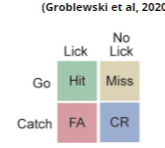

In [ ]:
#Go VIP/SST
#hit_sst_data = data[(data.cre_line == 'Sst-IRES-Cre')&(data.is_change == True)&(data.rewarded == True)]
#miss_sst_data = data[(data.cre_line == 'Sst-IRES-Cre')&(data.is_change == True)&(data.rewarded == False)]

#hit_vip_data = data[(data.cre_line == 'Vip-IRES-Cre')&(data.is_change == True)&(data.rewarded == True)]
#miss_vip_data = data[(data.cre_line == 'Vip-IRES-Cre')&(data.is_change == True)&(data.rewarded == False)]

#Catch VIP/SST
#cr_sst_data = data[(data.cre_line == 'Sst-IRES-Cre')&(data.is_change == False)&(data.RESPONSE == False)]
#fa_sst_data = data[(data.cre_line == 'Sst-IRES-Cre')&(data.is_change == False)&(data.RESPONSE == True)]

#cr_vip_data = data[(data.cre_line == 'Vip-IRES-Cre')&(data.is_change == False)&(data.RESPONSE == False)]
#fa_vip_data = data[(data.cre_line == 'Vip-IRES-Cre')&(data.is_change == False)&(data.RESPONSE == True)]


In [ ]:
#ts_sst = fa_sst_data.trace_timestamps.values[0]
#absolute_timestamp = ts_sst
#traces_sst = fa_sst_data.trace.values
#traces_vip = fa_vip_data.trace.values
#plt.plot(ts_sst,np.mean(traces_sst),label="SST",color="#0BBC9E")
#plt.plot(ts_sst,np.mean(traces_vip),label="VIP",color="#076C5B")
#plt.title(" False alarm (Catch) comparisson")
#plt.xlabel("Time")
#plt.ylabel("dF/F")
#plt.legend()

El reto de hoy: cómo vamos a realizar la regresión lineal

In [ ]:
#Pre procesamiento: necesitamos un set de X e Y sobre la respuesta
"""
Primero: trabajaremos solamente en catch

¿cúal catch? ¿únicamente FA? (Cami dijo <creo que sí..>)

Sabemos que Y es un vector booleano que podemos extraer de RESPONSE
Pero el vector de X? necesitamos saber como vincular E(VIP) y E(SST)

¿podemos asegurar que son siempre de las mismas filas/celulas?
"""
#X = np.array([fa_sst_data,fa_vip_data])
#Y = np.array(np.mean(fa_sst_data.RESPONSE))
#fa_sst_data.shape #cami dijo <uno es mayor que el otro ... profundo>

#set_vip = fa_vip_data
#set_sst = fa_sst_data
#min_rows = min(set_vip.shape[0],set_sst.shape[0])

#X = np.array([set_vip[:min_rows].trace.values,set_sst[:min_rows].trace.values]) #aproximación chambona de santiago, favor revisar sampling.
#X.shape
#Primer problema, VIP y SST en sus respectivas bolsas no tienen el mismo tamaño.

'\nPrimero: trabajaremos solamente en catch\n\n¿cúal catch? ¿únicamente FA? (Cami dijo <creo que sí..>)\n\nSabemos que Y es un vector booleano que podemos extraer de RESPONSE\nPero el vector de X? necesitamos saber como vincular E(VIP) y E(SST)\n\n¿podemos asegurar que son siempre de las mismas filas/celulas?\n'

# Posible resolución al inconveniente

Qué pasa si los agrupamos por ID de imagen?

Sabemos que por sesión el ID de imagen corresponde con la imagen estimulo; es decir que, para cada imagen tenemos la información de la fluorescencia de todas
las celulas SST y VIP involucradas (y por extensión su respuesta "grande" por parte del animal

## Posibles implicaciones

Toca separar las bolsas por sesión (lo mas seguro es que la imagen aparezca en ambas sesiones)

hay que revisar el caso para las omitted (esto muy muy después)

$ separar por sesión → agrupar por SPID → Hacer bolsas (VIP/SST)$

Note que de ahi saldrán los datos Y para la regresión :)

In [ ]:
#s3 = data[(data.session_number == 3.)]
#s4 = data[(data.session_number == 4.)]


In [ ]:
#m0 = data.mouse_id.unique()[0]
#mouse_0_info = data[(data.mouse_id == m0)]
#print(data.ophys_session_id.unique())

In [ ]:
''''
spidis = data.stimulus_presentations_id.unique()
list_of_candidates = []
data_spid = None
for spd in spidis:
  spid_data = data[(data.stimulus_presentations_id == spd)]
  if len(spid_data.cre_line.unique()) > 1:
    if data_spid is None:
      print("entered once, because I love you santiago")
      data_spid = spid_data
    else:
      data_spid = pd.concat([data_spid,spid_data])
    list_of_candidates.append(spd)

#list_of_candidate
  #print(f"ID: {spd} CRELINES : {spid_data.cre_line.unique()}")

'''

'\'\nspidis = data.stimulus_presentations_id.unique()\nlist_of_candidates = []\ndata_spid = None\nfor spd in spidis:\n  spid_data = data[(data.stimulus_presentations_id == spd)]\n  if len(spid_data.cre_line.unique()) > 1:\n    if data_spid is None:\n      print("entered once, because I love you santiago")\n      data_spid = spid_data\n    else:\n      data_spid = pd.concat([data_spid,spid_data])\n    list_of_candidates.append(spd)\n\n#list_of_candidate\n  #print(f"ID: {spd} CRELINES : {spid_data.cre_line.unique()}")\n\n'

In [ ]:
#len(list_of_candidates)

In [ ]:
#data_spid

In [ ]:
#Opcion B para filtrado
'''
data_spid = data_spid[(data_spid.is_change == False)] # aqui solo tomaremos los IDs que poseen pruebas Catch <no nos interesan los Go>
fa_data_spid = data_spid[(data_spid.RESPONSE == True)] #Bolsa para FA
cr_data_spid = data_spd[(data_spid.RESPONSE == False)] #Bolsa para CR
fa_data_spid
'''


'\ndata_spid = data_spid[(data_spid.is_change == False)] # aqui solo tomaremos los IDs que poseen pruebas Catch <no nos interesan los Go> \nfa_data_spid = data_spid[(data_spid.RESPONSE == True)] #Bolsa para FA\ncr_data_spid = data_spd[(data_spid.RESPONSE == False)] #Bolsa para CR\nfa_data_spid\n'

In [ ]:
#Dentro de la bolsa de FA, vamos a mirar cada ID y crear los vectores X,Y
'''
Y = []
vec_sst = []
vec_vip = ]
for id in fa_data_spid.stimulus_presentations_id.unique():
    data_current_id = fa_data_spid[(fa_data_spid.stimulus_presentations_id == id)] #la información filtrada por ID y por FA
    for dat in data_current_id:
      if dat.cre_line == "Sst-IRES-Cre":
        vec_sst.append(dat.RESPONSE)
      elif dat.cre_line == "Vip-IRES-Cre":
            vec_vip.append(dat.RESPONSE)
'''

'\nY = []\nvec_sst = []\nvec_vip = ]\nfor id in fa_data_spid.stimulus_presentations_id.unique():\n    data_current_id = fa_data_spid[(fa_data_spid.stimulus_presentations_id == id)] #la información filtrada por ID y por FA\n    for dat in data_current_id:\n      if dat.cre_line == "Sst-IRES-Cre":\n        vec_sst.append(dat.RESPONSE)\n      elif dat.cre_line == "Vip-IRES-Cre":\n            vec_vip.append(dat.RESPONSE)\n'

In [ ]:
'''
#Ahora si podemos empezar el pre-proccessing
#mision 1: crear las X
#crear las bolsas < cami bautiza a la unidad minima estructural: pelotita >



id_1 = data_spid.stimulus_presentations_id.unique()[0]
data_id_1 = data_spid[(data_spid.stimulus_presentations_id == id_1)]

short_fa_sst_data = data_id_1[(data_id_1.cre_line == 'Sst-IRES-Cre')&(data_id_1.is_change == False)&(data_id_1.RESPONSE == True)]
short_fa_vip_data = data_id_1[(data_id_1.cre_line == 'Vip-IRES-Cre')&(data_id_1.is_change == False)&(data_id_1.RESPONSE == True)]

ts_sst = short_fa_sst_data.trace_timestamps.values[0]

traces_sst = short_fa_sst_data.trace.values
traces_vip = short_fa_vip_data.trace.values
plt.plot(ts_sst,np.mean(traces_sst),label="SST",color="#0BBC9E")
plt.plot(ts_sst,np.mean(traces_vip),label="VIP",color="#076C5B")
plt.title(" False alarm (Catch) comparisson")
plt.xlabel("Time")
plt.ylabel("dF/F")
plt.legend()
#Verificamos que nuestro filtro/sub base presenta los mismos patrones

'''


'\n#Ahora si podemos empezar el pre-proccessing\n#mision 1: crear las X\n#crear las bolsas < cami bautiza a la unidad minima estructural: pelotita >\n\n\n\nid_1 = data_spid.stimulus_presentations_id.unique()[0]\ndata_id_1 = data_spid[(data_spid.stimulus_presentations_id == id_1)]\n\nshort_fa_sst_data = data_id_1[(data_id_1.cre_line == \'Sst-IRES-Cre\')&(data_id_1.is_change == False)&(data_id_1.RESPONSE == True)]\nshort_fa_vip_data = data_id_1[(data_id_1.cre_line == \'Vip-IRES-Cre\')&(data_id_1.is_change == False)&(data_id_1.RESPONSE == True)]\n\nts_sst = short_fa_sst_data.trace_timestamps.values[0]\n\ntraces_sst = short_fa_sst_data.trace.values\ntraces_vip = short_fa_vip_data.trace.values\nplt.plot(ts_sst,np.mean(traces_sst),label="SST",color="#0BBC9E")\nplt.plot(ts_sst,np.mean(traces_vip),label="VIP",color="#076C5B")\nplt.title(" False alarm (Catch) comparisson")\nplt.xlabel("Time")\nplt.ylabel("dF/F")\nplt.legend()\n#Verificamos que nuestro filtro/sub base presenta los mismos patrone

In [ ]:
'''
fil = data_id_1[(data_id_1.cre_line == 'Sst-IRES-Cre')&(data_id_1.is_change == False)&(data_id_1.RESPONSE == True)]
fi

'''

"\nfil = data_id_1[(data_id_1.cre_line == 'Sst-IRES-Cre')&(data_id_1.is_change == False)&(data_id_1.RESPONSE == True)]\nfi\n\n"

In [ ]:

# Sabemos que cada SPID nos indica que el estimulo y la respuesta corresponden al mismo grupo de celulas bien sean VIP o SST
# Esto quiere decir que, Y[VIP o SST] =  x1[VIP] + x2[SST]

# Regresión logística y SVM

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

In [ ]:
sst_data = data[(data.cre_line == "Sst-IRES-Cre")] #todo trial que tenga las SST
vip_data = data[(data.cre_line == "Vip-IRES-Cre")] #todo trial que tenga las VIP

"""
FASE A: crear la regresión con todos los datos | uno para vip y otro para sst
"""
Y_vip = vip_data["RESPONSE"]
X_vip = vip_data["trace"].values

Y_sst = sst_data["RESPONSE"]
X_sst = sst_data["trace"].values

#vip_LR_model = LogisticRegression().fit(X_vip,Y_vip)
#sst_LR_model = LogisticRegression().fit(X_sst,Y_sst)


In [ ]:
from sklearn import svm, model_selection
#Filtrar catch y omitted (La bolsa)
catch_data = data[(data.is_change == False)] #tenemos ambos CR y FA
#Extraer datos
vip_c = catch_data[(catch_data.cre_line == "Vip-IRES-Cre")]
sst_c = catch_data[(catch_data.cre_line == "Sst-IRES-Cre")]
Y_vip_c = vip_c.RESPONSE
Y_sst_c = sst_c.RESPONSE
X_vip_c = vip_c["trace"].values
X_sst_c = sst_c["trace"].values

In [ ]:
vip_c

In [ ]:
data_k = vip_c[(vip_c.stimulus_presentations_id == 1)]

In [ ]:
data_kk = data_k[(data_k.is_change == False)]

In [ ]:
data_kkk = data_kk[(data_kk.cre_line == "Vip-IRES-Cre")]
data_kkk

In [ ]:
x_kkk = data_kkk['trace'].values
x_kkk

In [ ]:
x_kkk.shape

(42,)

In [ ]:
x_kkk_reshaped = np.array(list(x_kkk))
x_kkk_reshaped.shape

(42, 85)

In [ ]:
x_kkk_reshaped[:,0]

array([-0.02781186,  0.04503218, -0.00565206, -0.05011496, -0.05836399,
        0.06881716, -0.01606512,  0.09376349, -0.04800597,  0.        ,
        0.05080126, -0.05956914, -0.055603  ,  0.02831124, -0.27648589,
       -0.02725133, -0.02441494, -0.13063945,  0.07795123,  0.03887122,
        0.07510436, -0.11211585, -0.04587641, -0.18934987, -0.05101074,
       -0.04038928,  0.02698804,  0.0629478 ,  0.10315848, -0.10709095,
       -0.02993602, -0.11847279, -0.00571928,  0.16682017, -0.02562503,
       -0.0496063 , -0.02393164,  0.05951962, -0.02048595,  0.21008776,
       -0.06189445,  0.03456086])

In [ ]:
#train test para vip
X_vip_train, X_vip_test, Y_vip_train, Y_vip_test = model_selection.train_test_split(X_vip_c,Y_vip_c,train_size=0.85,random_state=21)
#train test para sst
X_sst_train, X_sst_test, Y_sst_train, Y_sst_test = model_selection.train_test_split(X_sst_c,Y_sst_c,train_size=0.85,random_state=21)

In [ ]:
#reshaping vars

X_vip_train_list_reshaped = np.array(list(X_vip_train))
Y_vip_train_list_reshaped = np.array(list(Y_vip_train.values*1))

X_vip_test_list_reshaped = np.array(list(X_vip_test))
Y_vip_test_list_reshaped = np.array(list(Y_vip_test.values*1))


In [ ]:
X_vip_train_list_reshaped.shape

(31111, 85)

[]

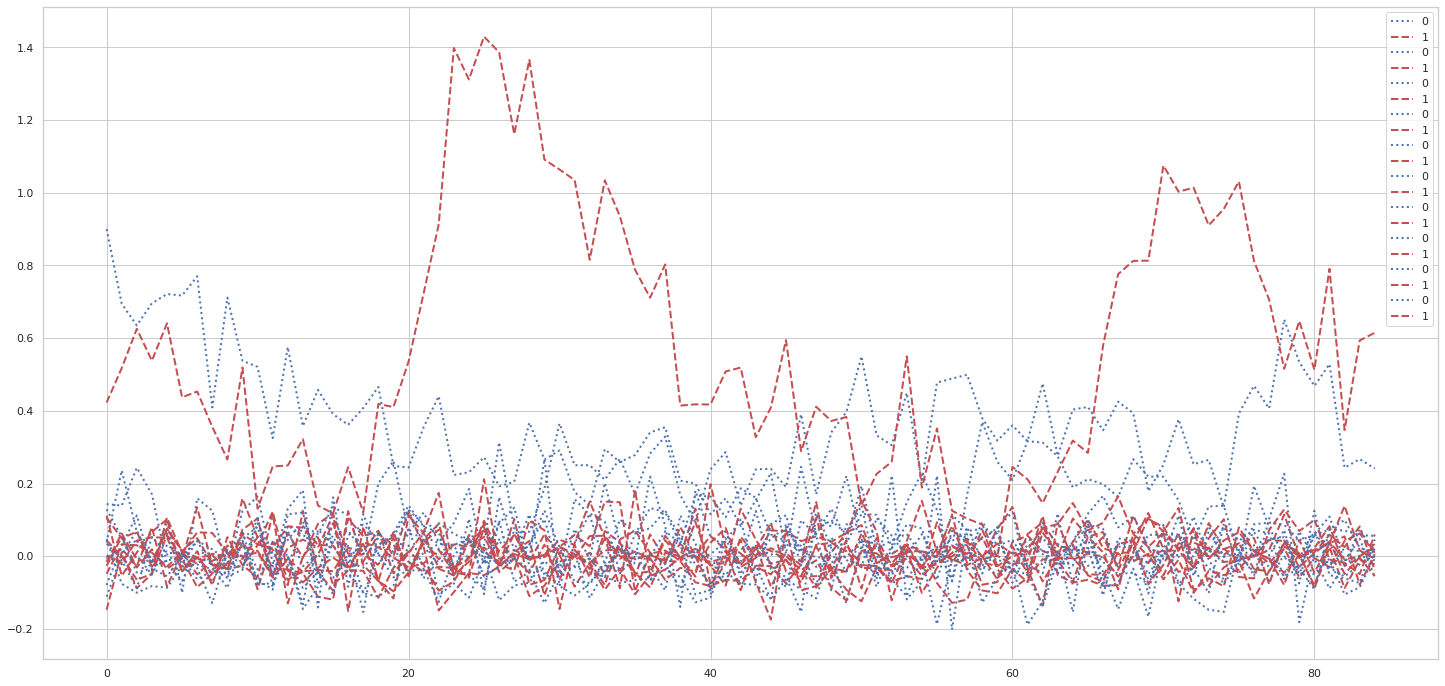

In [ ]:
plt.figure(figsize=(25,12))
X0 = X_vip_train_list_reshaped[Y_vip_train_list_reshaped==0]
X1 = X_vip_train_list_reshaped[Y_vip_train_list_reshaped==1]
for k in range(10):
  plt.plot(X0[k],ls=':',lw=2,label='0',color='b')
  plt.plot(X1[k],ls='--',lw=2,label='1',color='r')
plt.legend()
plt.plot()

In [ ]:
#Y_vip_train_reshaped = (Y_vip_train.values*1).reshape(-1,1)

In [ ]:
Y_vip_train_list_reshaped.shape

(31111,)

In [ ]:
#SVM es lo mismo pero con otro nombre
regr = LogisticRegression(random_state=0).fit(X_vip_train_list_reshaped, Y_vip_train_list_reshaped)

In [ ]:
print(regr.intercept_)

[-1.66585932]


In [ ]:
y_pred = regr.predict(X_vip_test_list_reshaped)


In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
len(y_pred)

5491

In [ ]:
count = 0
for k in y_pred:
  count += k
print(count)

2


In [ ]:
Y_vip_test_list_reshaped

array([1, 0, 1, ..., 0, 0, 0])

In [ ]:
count = 0
for k in Y_vip_test_list_reshaped:
  count += k
print(count)

865


In [ ]:
df_preds = pd.DataFrame({'Actual': Y_vip_test_list_reshaped.squeeze(), 'Predicted': y_pred.squeeze()})
df_preds
df = df_preds
pd.set_option('display.max_rows', df.shape[0]+1)
#print(df)

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
svmregr = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svmregr.fit(X_vip_train_list_reshaped, Y_vip_train_list_reshaped)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))])

In [ ]:
y_pred = svmregr.predict(X_vip_test_list_reshaped)

In [ ]:
count = 0
for k in y_pred:
  count += k
print(count)

0
